In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: mps


In [3]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [4]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [5]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================




# ==========================================
# 4.1 ADDITIONAL IMPORTS
# ==========================================

# so here i am importing some extra libraries that we need for plotting and analysis
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

print(" libraries imported")

 libraries imported


In [ ]:
# ==========================================
# 4.2 PART A: THE PANCAKE MODEL (Width Focus)
# ==========================================

print("\n[PART A] Building Pancake Model - Wide but Shallow")

class PancakeMLP(nn.Module):
    """
    Pancake Model: Wide but Shallow
    Using 1-2 hidden layers with many neurons
    Testing if raw memorization power solves the problem
    """
    def __init__(self, input_size=784, num_classes=15):
        super(PancakeMLP, self).__init__()
        
        # so for pancake i am using just 2 hidden layers but they are very wide
        # BUT keeping it UNDER 3 MILLION parameters
        
        # first hidden layer: 1536 neurons (reduced from 2048)
        self.fc1 = nn.Linear(input_size, 1536)
        
        # second hidden layer: 1024 neurons
        self.fc2 = nn.Linear(1536, 1024)
        
        # adding dropout so it doesn't overfit too much
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.3)
        
        # output layer gives us 15 classes
        self.fc3 = nn.Linear(1024, num_classes)
        
        # let me see how many parameters this model has
        params = sum(p.numel() for p in self.parameters())
        print(f"  Pancake model parameters: {params:,}")
        if params > 3000000:
            print(f"  ⚠️ WARNING: Over 3M limit by {params - 3000000:,} parameters!")
        else:
            print(f"  ✅ Within 3M limit, {3000000 - params:,} parameters remaining")
        
    def forward(self, x):
        # first flatten the 28x28 image into 784 numbers
        x = x.view(-1, 784)
        
        # first layer with relu activation
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout1(x)
        
        # second layer
        x = self.fc2(x)
        x = torch.relu(x)
        x = self.dropout2(x)
        
        # output layer gives us predictions
        x = self.fc3(x)
        
        return x

#  So, here just checking if model works
test_model = PancakeMLP()
print("Pancake model defined successfully")


[PART A] Building Pancake Model - Wide but Shallow
  Pancake model parameters: 2,795,023
  ✅ Within 3M limit, 204,977 parameters remaining
Pancake model defined successfully


In [ ]:
# ==========================================
# 4.3 PART B: THE TOWER MODEL (Depth Focus - IMPROVED)
# ==========================================

print("\n[PART B] Building Tower Model - Deep but Narrow (IMPROVED)")

class TowerMLP(nn.Module):
    """
    Tower Model: Deep but Narrow - Improved version
    """
    def __init__(self, input_size=784, num_classes=15):
        super(TowerMLP, self).__init__()
        
        # Sol, here for tower i am using 6 hidden layers (reduced from 8)
        # each has 256 neurons (increased from 128)
        # So, this should help with underfitting
        
        # input layer
        self.fc_in = nn.Linear(input_size, 256)
        self.bn_in = nn.BatchNorm1d(256)
        
        # 6 hidden layers
        self.fc1 = nn.Linear(256, 256)
        self.bn1 = nn.BatchNorm1d(256)
        
        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256)
        
        self.fc3 = nn.Linear(256, 256)
        self.bn3 = nn.BatchNorm1d(256)
        
        self.fc4 = nn.Linear(256, 256)
        self.bn4 = nn.BatchNorm1d(256)
        
        self.fc5 = nn.Linear(256, 256)
        self.bn5 = nn.BatchNorm1d(256)
        
        self.fc6 = nn.Linear(256, 256)
        self.bn6 = nn.BatchNorm1d(256)
        
        # dropout
        self.dropout = nn.Dropout(0.2)
        
        # output layer
        self.fc_out = nn.Linear(256, num_classes)
        
        # let's count parameters
        params = sum(p.numel() for p in self.parameters())
        print(f"  Tower model parameters: {params:,}")
        
    def forward(self, x):
        x = x.view(-1, 784)
        
        # input layer
        x = self.fc_in(x)
        x = self.bn_in(x)
        x = torch.relu(x)
        
        # hidden layer 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # hidden layer 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # hidden layer 3
        x = self.fc3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # hidden layer 4
        x = self.fc4(x)
        x = self.bn4(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # hidden layer 5
        x = self.fc5(x)
        x = self.bn5(x)
        x = torch.relu(x)
        x = self.dropout(x)
        
        # hidden layer 6
        x = self.fc6(x)
        x = self.bn6(x)
        x = torch.relu(x)
        
        # output layer
        x = self.fc_out(x)
        
        return x

# quick test
test_model = TowerMLP()
print("✅ Improved Tower model defined successfully")


[PART B] Building Tower Model - Deep but Narrow (IMPROVED)
  Tower model parameters: 603,151
✅ Improved Tower model defined successfully


In [ ]:
# ==========================================
# 4.4 PART C: THE CHAMPION MODEL 
# ==========================================

print("\n[PART C] Building Champion Model - BALANCED VERSION")

class ChampionMLP(nn.Module):
    """
    Champion Model: Balanced to prevent overfitting
    """
    def __init__(self, input_size=784, num_classes=15):
        super(ChampionMLP, self).__init__()
        
        
        # input layer: 784 -> 512
        self.fc_in = nn.Linear(input_size, 512)
        self.bn_in = nn.BatchNorm1d(512)
        
        # layer 1: 512 -> 384
        self.fc1 = nn.Linear(512, 384)
        self.bn1 = nn.BatchNorm1d(384)
        
        # layer 2: 384 -> 256
        self.fc2 = nn.Linear(384, 256)
        self.bn2 = nn.BatchNorm1d(256)
        
        # layer 3: 256 -> 256
        self.fc3 = nn.Linear(256, 256)
        self.bn3 = nn.BatchNorm1d(256)
        
        # layer 4: 256 -> 128
        self.fc4 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)
        
        # output layer
        self.fc_out = nn.Linear(128, num_classes)
        
        self.dropout_in = nn.Dropout(0.2)      # increased from 0.1
        self.dropout1 = nn.Dropout(0.3)        # increased from 0.2
        self.dropout2 = nn.Dropout(0.4)        # increased from 0.25
        self.dropout3 = nn.Dropout(0.4)        # increased from 0.3
        self.dropout4 = nn.Dropout(0.3)        # increased from 0.25
        
        # let's check parameter count
        params = sum(p.numel() for p in self.parameters())
        print(f"  Champion model parameters: {params:,}")
        if params < 3000000:
            print(f"  ✅ Within 3M limit, {3000000 - params:,} parameters remaining")
        
    def forward(self, x):
        x = x.view(-1, 784)
        
        # input layer
        x = self.fc_in(x)
        x = self.bn_in(x)
        x = torch.relu(x)
        x = self.dropout_in(x)
        
        # layer 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout1(x)
        
        # layer 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout2(x)
        
        # layer 3
        x = self.fc3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.dropout3(x)
        
        # layer 4
        x = self.fc4(x)
        x = self.bn4(x)
        x = torch.relu(x)
        x = self.dropout4(x)
        
        # output layer
        x = self.fc_out(x)
        
        return x

# quick test
test_model = ChampionMLP()
print("✅ Balanced Champion model defined successfully")


[PART C] Building Champion Model - BALANCED VERSION
  Champion model parameters: 801,167
  ✅ Within 3M limit, 2,198,833 parameters remaining
✅ Balanced Champion model defined successfully


In [ ]:
# ==========================================
# 4.5 TRAINING FUNCTION (WITH REGULARIZATION)
# ==========================================

def train_model(model, train_loader, val_loader, epochs, model_name="Model"):
    """
    Training function with stronger regularization
    """
    print(f"\n--- Training {model_name} ---")
    device = DEVICE
    model = model.to(device)
    
    # loss function
    criterion = nn.CrossEntropyLoss()
    
    # So, here INCREASED weight decay from 1e-4 to 5e-4 for more regularization
    optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=5e-4)
    
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=0.002,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.3
    )
    
    # early stopping
    best_val_acc = 0
    best_model_state = None
    patience_counter = 0
    patience_limit = 10
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(epochs):
        # training phase
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)
            
            outputs = model(data)
            loss = criterion(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += targets.size(0)
            train_correct += predicted.eq(targets).sum().item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        
        # validation phase
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                loss = criterion(outputs, targets)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)
        
        # print progress
        current_lr = optimizer.param_groups[0]["lr"]
        print(f'Epoch {epoch+1}/{epochs}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%, LR: {current_lr:.6f}')
        
        # check if this is the best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f" Val Acc: {val_acc:.2f}%")
        else:
            patience_counter += 1
            
        # early stopping
        if patience_counter >= patience_limit:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break
    
    # load the best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✅ Loaded best model with Val Acc: {best_val_acc:.2f}%")
    
    return model, train_accs, val_accs, train_losses, val_losses

print("✅ Regularized training function defined")

✅ Regularized training function defined


In [ ]:
# ==========================================
# 4.6 TRAIN PANCAKE MODEL (Part A)
# ==========================================

print("\n" + "="*60)
print("TRAINING PANCAKE MODEL (PART A)")
print("="*60)

pancake_epochs = 20

# So, here creating and training the pancake model
pancake_model = PancakeMLP()
pancake_model, p_train_acc, p_val_acc, p_train_loss, p_val_loss = train_model(
    pancake_model, train_loader, val_loader, epochs=pancake_epochs, model_name="Pancake"
)

# So, here storing results so we can use them later for comparison
pancake_results = {
    'train_acc': p_train_acc,
    'val_acc': p_val_acc,
    'train_loss': p_train_loss,
    'val_loss': p_val_loss,
    'params': sum(p.numel() for p in pancake_model.parameters())
}

print(f"\nPancake model training complete!")
print(f"   Final Train Accuracy: {p_train_acc[-1]:.2f}%")
print(f"   Final Val Accuracy: {p_val_acc[-1]:.2f}%")


TRAINING PANCAKE MODEL (PART A)
  Pancake model parameters: 2,795,023
  ✅ Within 3M limit, 204,977 parameters remaining

--- Training Pancake ---
Epoch 1/20: Train Acc: 47.83%, Val Acc: 61.75%, LR: 0.000209
 Val Acc: 61.75%
Epoch 2/20: Train Acc: 64.76%, Val Acc: 67.58%, LR: 0.000560
 Val Acc: 67.58%
Epoch 3/20: Train Acc: 68.97%, Val Acc: 69.34%, LR: 0.001041
 Val Acc: 69.34%
Epoch 4/20: Train Acc: 71.02%, Val Acc: 71.00%, LR: 0.001521
 Val Acc: 71.00%
Epoch 5/20: Train Acc: 72.81%, Val Acc: 73.12%, LR: 0.001872
 Val Acc: 73.12%
Epoch 6/20: Train Acc: 74.00%, Val Acc: 73.90%, LR: 0.002000
 Val Acc: 73.90%
Epoch 7/20: Train Acc: 75.82%, Val Acc: 74.19%, LR: 0.001975
 Val Acc: 74.19%
Epoch 8/20: Train Acc: 77.44%, Val Acc: 75.19%, LR: 0.001901
 Val Acc: 75.19%
Epoch 9/20: Train Acc: 79.31%, Val Acc: 75.47%, LR: 0.001781
 Val Acc: 75.47%
Epoch 10/20: Train Acc: 81.26%, Val Acc: 76.62%, LR: 0.001623
 Val Acc: 76.62%
Epoch 11/20: Train Acc: 83.23%, Val Acc: 77.20%, LR: 0.001433
 Val Acc: 

In [ ]:
# ==========================================
# 4.7 TRAIN TOWER MODEL (Part B)
# ==========================================

print("\n" + "="*60)
print("TRAINING TOWER MODEL (PART B)")
print("="*60)

tower_epochs = 20

# So, here creating and training the tower model
tower_model = TowerMLP()
tower_model, t_train_acc, t_val_acc, t_train_loss, t_val_loss = train_model(
    tower_model, train_loader, val_loader, epochs=tower_epochs, model_name="Tower"
)

# So, here storing results
tower_results = {
    'train_acc': t_train_acc,
    'val_acc': t_val_acc,
    'train_loss': t_train_loss,
    'val_loss': t_val_loss,
    'params': sum(p.numel() for p in tower_model.parameters())
}

print(f"\nTower model training complete!")
print(f"   Final Train Accuracy: {t_train_acc[-1]:.2f}%")
print(f"   Final Val Accuracy: {t_val_acc[-1]:.2f}%")


TRAINING TOWER MODEL (PART B)
  Tower model parameters: 603,151

--- Training Tower ---
Epoch 1/20: Train Acc: 35.20%, Val Acc: 61.98%, LR: 0.000209
 Val Acc: 61.98%
Epoch 2/20: Train Acc: 62.93%, Val Acc: 69.74%, LR: 0.000560
 Val Acc: 69.74%
Epoch 3/20: Train Acc: 67.38%, Val Acc: 71.31%, LR: 0.001041
 Val Acc: 71.31%
Epoch 4/20: Train Acc: 69.46%, Val Acc: 70.40%, LR: 0.001521
Epoch 5/20: Train Acc: 71.43%, Val Acc: 73.78%, LR: 0.001872
 Val Acc: 73.78%
Epoch 6/20: Train Acc: 74.08%, Val Acc: 75.33%, LR: 0.002000
 Val Acc: 75.33%
Epoch 7/20: Train Acc: 76.25%, Val Acc: 76.22%, LR: 0.001975
 Val Acc: 76.22%
Epoch 8/20: Train Acc: 78.52%, Val Acc: 76.63%, LR: 0.001901
 Val Acc: 76.63%
Epoch 9/20: Train Acc: 80.25%, Val Acc: 77.18%, LR: 0.001781
 Val Acc: 77.18%
Epoch 10/20: Train Acc: 81.85%, Val Acc: 77.36%, LR: 0.001623
 Val Acc: 77.36%
Epoch 11/20: Train Acc: 83.34%, Val Acc: 77.82%, LR: 0.001433
 Val Acc: 77.82%
Epoch 12/20: Train Acc: 84.64%, Val Acc: 78.53%, LR: 0.001222
 Val A

In [ ]:
# ==========================================
# 4.8 TRAIN CHAMPION MODEL (Part C) 
# ==========================================

print("\n" + "="*60)
print("TRAINING CHAMPION MODEL (PART C) - BEST VERSION")
print("="*60)

champion_epochs = 20

# So, here creating and training the champion model
champion_model = ChampionMLP()
champion_model, c_train_acc, c_val_acc, c_train_loss, c_val_loss = train_model(
    champion_model, train_loader, val_loader, epochs=champion_epochs, model_name="Champion"
)

# So, here storing results
champion_results = {
    'train_acc': c_train_acc,
    'val_acc': c_val_acc,
    'train_loss': c_train_loss,
    'val_loss': c_val_loss,
    'params': sum(p.numel() for p in champion_model.parameters())
}

print(f"\nChampion model training complete!")
print(f"   Final Train Accuracy: {c_train_acc[-1]:.2f}%")
print(f"   Final Val Accuracy: {c_val_acc[-1]:.2f}%")
print(f"   Best Val Accuracy: {max(c_val_acc):.2f}%")

#  So, here saving the champion model
torch.save(champion_model.state_dict(), 'champion_model_best.pth')
print("Champion model saved as 'champion_model_best.pth'")


TRAINING CHAMPION MODEL (PART C) - BEST VERSION
  Champion model parameters: 801,167
  ✅ Within 3M limit, 2,198,833 parameters remaining

--- Training Champion ---
Epoch 1/20: Train Acc: 28.32%, Val Acc: 57.68%, LR: 0.000209
 Val Acc: 57.68%
Epoch 2/20: Train Acc: 59.03%, Val Acc: 68.78%, LR: 0.000560
 Val Acc: 68.78%
Epoch 3/20: Train Acc: 65.72%, Val Acc: 70.72%, LR: 0.001041
 Val Acc: 70.72%
Epoch 4/20: Train Acc: 68.37%, Val Acc: 72.17%, LR: 0.001521
 Val Acc: 72.17%
Epoch 5/20: Train Acc: 70.15%, Val Acc: 72.21%, LR: 0.001872
 Val Acc: 72.21%
Epoch 6/20: Train Acc: 72.43%, Val Acc: 74.36%, LR: 0.002000
 Val Acc: 74.36%
Epoch 7/20: Train Acc: 74.63%, Val Acc: 76.03%, LR: 0.001975
 Val Acc: 76.03%
Epoch 8/20: Train Acc: 76.47%, Val Acc: 76.85%, LR: 0.001901
 Val Acc: 76.85%
Epoch 9/20: Train Acc: 78.27%, Val Acc: 76.92%, LR: 0.001781
 Val Acc: 76.92%
Epoch 10/20: Train Acc: 79.54%, Val Acc: 78.05%, LR: 0.001623
 Val Acc: 78.05%
Epoch 11/20: Train Acc: 81.13%, Val Acc: 78.20%, LR: 0


PLOTTING COMPARISON CURVES


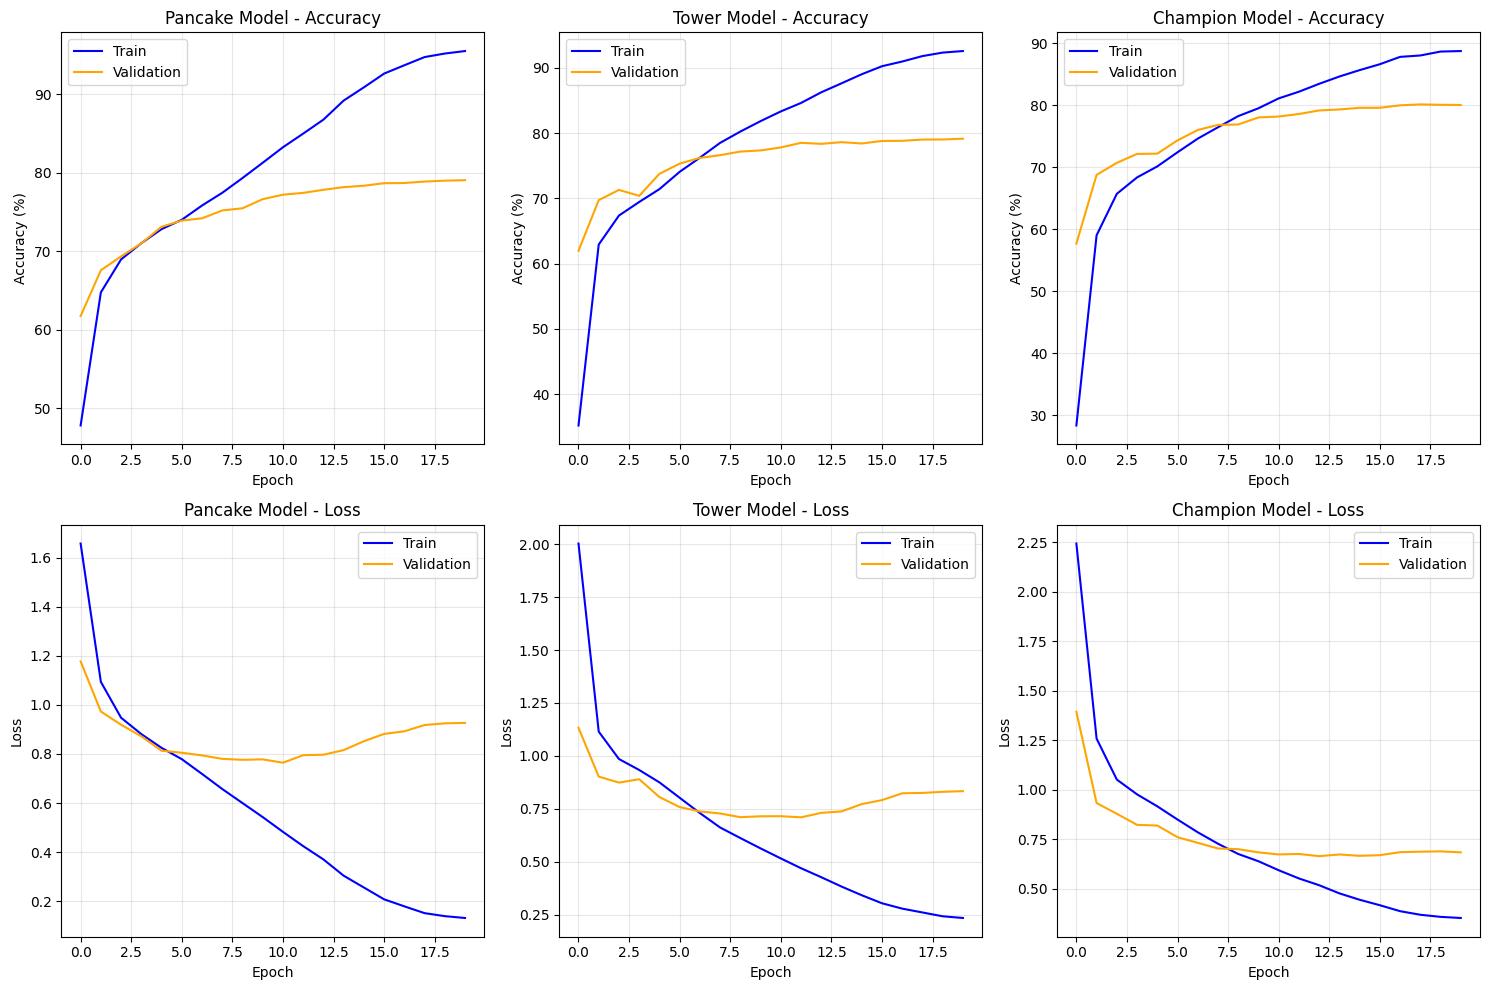

Comparison plots saved as 'model_comparison.png'


In [ ]:
# ==========================================
# 4.9 PLOT COMPARISON CURVES
# ==========================================

print("\n" + "="*60)
print("PLOTTING COMPARISON CURVES")
print("="*60)

# So, here making a figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# pancake accuracy plot
axes[0,0].plot(pancake_results['train_acc'], label='Train', color='blue')
axes[0,0].plot(pancake_results['val_acc'], label='Validation', color='orange')
axes[0,0].set_title('Pancake Model - Accuracy')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy (%)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# pancake loss plot
axes[1,0].plot(pancake_results['train_loss'], label='Train', color='blue')
axes[1,0].plot(pancake_results['val_loss'], label='Validation', color='orange')
axes[1,0].set_title('Pancake Model - Loss')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# tower accuracy plot
axes[0,1].plot(tower_results['train_acc'], label='Train', color='blue')
axes[0,1].plot(tower_results['val_acc'], label='Validation', color='orange')
axes[0,1].set_title('Tower Model - Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# tower loss plot
axes[1,1].plot(tower_results['train_loss'], label='Train', color='blue')
axes[1,1].plot(tower_results['val_loss'], label='Validation', color='orange')
axes[1,1].set_title('Tower Model - Loss')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Loss')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

axes[0,2].plot(champion_results['train_acc'], label='Train', color='blue')
axes[0,2].plot(champion_results['val_acc'], label='Validation', color='orange')
axes[0,2].set_title('Champion Model - Accuracy')
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Accuracy (%)')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

axes[1,2].plot(champion_results['train_loss'], label='Train', color='blue')
axes[1,2].plot(champion_results['val_loss'], label='Validation', color='orange')
axes[1,2].set_title('Champion Model - Loss')
axes[1,2].set_xlabel('Epoch')
axes[1,2].set_ylabel('Loss')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

# So, here adjusting layout so nothing overlaps
plt.tight_layout()
# So, here saving the figure for my report
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Comparison plots saved as 'model_comparison.png'")

In [ ]:
# ==========================================
# 4.10 DISPLAY COMPARISON TABLE
# ==========================================

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

# So, here printing a nice table comparing all three models
print("\n{:<15} {:>15} {:>15} {:>15} {:>15}".format(
    "Model", "Parameters", "Train Acc", "Val Acc", "Epochs"
))
print("-" * 75)

# So, here putting all model info in a list
models_info = [
    ("Pancake", pancake_results['params'], 
     pancake_results['train_acc'][-1], pancake_results['val_acc'][-1], pancake_epochs),
    ("Tower", tower_results['params'],
     tower_results['train_acc'][-1], tower_results['val_acc'][-1], tower_epochs),
    ("Champion", champion_results['params'],
     champion_results['train_acc'][-1], champion_results['val_acc'][-1], champion_epochs),
]

# printing each row
for name, params, train_acc, val_acc, epochs in models_info:
    print("{:<15} {:>15,} {:>14.2f}% {:>14.2f}% {:>14}".format(
        name, params, train_acc, val_acc, epochs
    ))




MODEL COMPARISON SUMMARY

Model                Parameters       Train Acc         Val Acc          Epochs
---------------------------------------------------------------------------
Pancake               2,795,023          95.47%          79.04%             20
Tower                   603,151          92.59%          79.16%             20
Champion                801,167          88.77%          80.07%             20



GENERATING CONFUSION MATRIX


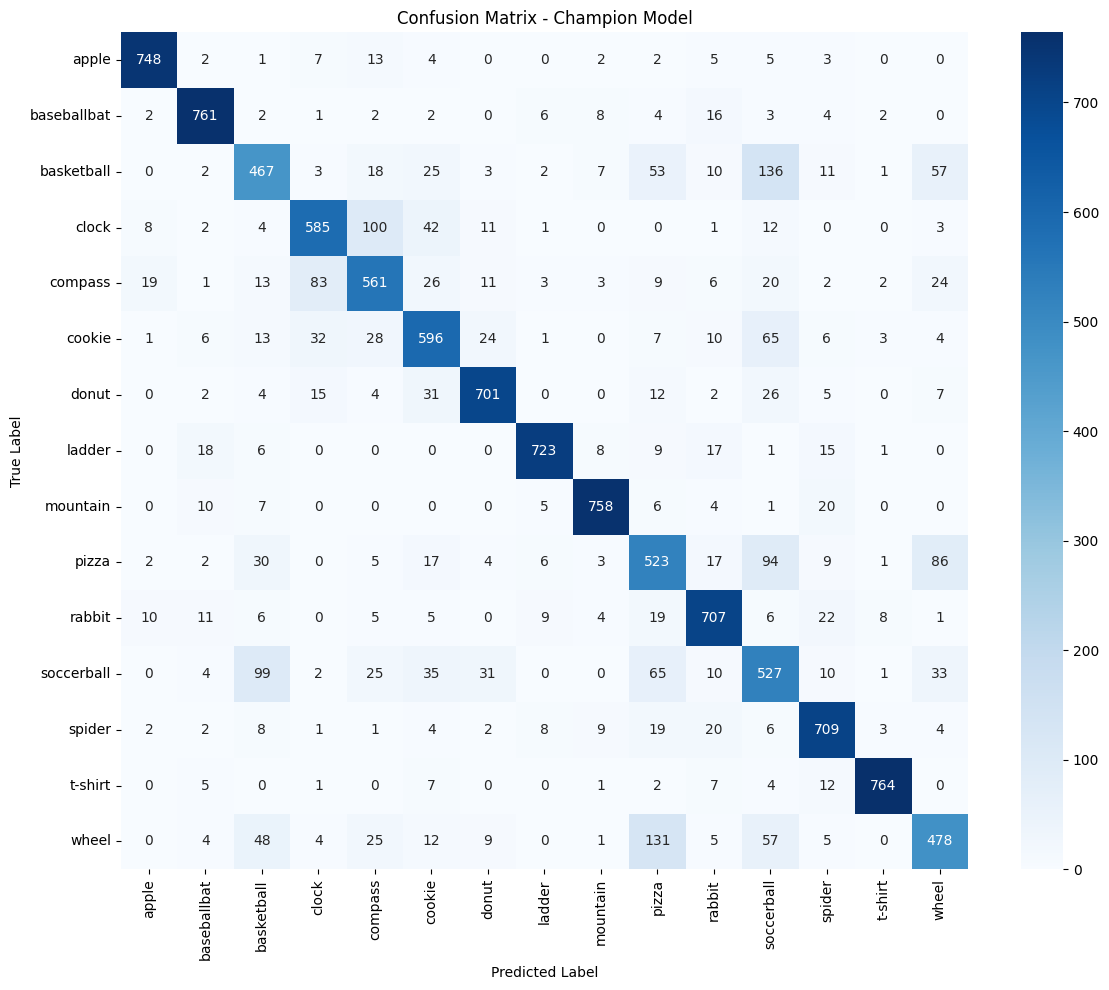


Top 2 Most Confused Pairs:
  wheel vs pizza: 131 times
  basketball vs soccerball: 136 times
Confusion matrix saved as 'confusion_matrix.png'


In [15]:
# ==========================================
# 4.11 CONFUSION MATRIX ANALYSIS
# ==========================================

print("\n" + "="*60)
print("GENERATING CONFUSION MATRIX")
print("="*60)

# function to create and plot confusion matrix
def plot_confusion_matrix(model, val_loader, class_names):
    model.eval()
    model.to(DEVICE)
    
    all_preds = []
    all_labels = []
    
    # get all predictions and true labels
    with torch.no_grad():
        for data, targets in val_loader:
            data = data.to(DEVICE)
            outputs = model(data)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.numpy())
    
    # create confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # plot it nicely
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Champion Model')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # find which classes the model gets confused about
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)  # set diagonal to 0 so we only see mistakes
    
    # get top 2 most confused pairs
    flat_indices = np.argsort(cm_no_diag.flatten())[-2:]
    
    print("\nTop 2 Most Confused Pairs:")
    for idx in flat_indices:
        true_idx = idx // len(class_names)
        pred_idx = idx % len(class_names)
        if true_idx != pred_idx and cm_no_diag[true_idx, pred_idx] > 0:
            print(f"  {class_names[true_idx]} vs {class_names[pred_idx]}: {cm[true_idx, pred_idx]} times")
    
    return cm

# get class names from the dataset
if hasattr(full_train_dataset, 'classes'):
    class_names = full_train_dataset.classes.tolist()
else:
    class_names = CLASSES  # using the list from earlier

# generate confusion matrix for champion model
cm = plot_confusion_matrix(champion_model, val_loader, class_names)
print("Confusion matrix saved as 'confusion_matrix.png'")

In [16]:
# ==========================================
# SET MODEL FOR PREDICTIONS
# ==========================================

# so here i am telling the notebook to use my champion model for predictions
model = champion_model
print("Using champion model for inference")

Using champion model for inference


In [19]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [18]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  WARNING: You are over the 3M parameter limit!")
    else:
        print("  Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 801,167
  Parameter count is within limits.
